**Parameter Estimation**
========================

In [2]:
import pandas as pd
import lmoments3 as lm
from lmoments3 import distr

# Step 1: Read CSV file and extract 'Max Value (mm)' column
file_path = 'C:\\Users\\khfy3\\OneDrive\\Desktop\\Master Final Sem\\Coding\\Data\\Daily\\0600011RF.csv'
data = pd.read_csv(file_path)['Value (mm)']

# Step 2: Install and Import lmoments3 (assuming lmoments3 is already installed)

# Step 3: Estimate L-moments from the data
l_moments = lm.lmom_ratios(data, nmom=4)

# Step 4 & 5: Fit distributions and estimate parameters
distributions = ['gum', 'nor', 'exp', 'gev', 'glo', 'gno', 'gpa', 'pe3','kap']
estimated_parameters = {}

for dist_name in distributions:
    dist = getattr(distr, dist_name)
    params = dist.lmom_fit(data)
    estimated_parameters[dist_name] = dict(params)

# Print estimated parameters for each distribution
for dist_name, params in estimated_parameters.items():
    print(f"{dist_name.upper()} Distribution Parameters: {params}")


GUM Distribution Parameters: {'loc': 2.234237508777153, 'scale': 9.408102171501575}
NOR Distribution Parameters: {'loc': 7.66474145916199, 'scale': 11.558525156720167}
EXP Distribution Parameters: {'loc': -5.377657530030442, 'scale': 13.042398989192431}
GEV Distribution Parameters: {'c': -0.7346536741178525, 'loc': 0.7283751961770246, 'scale': 2.1192902229559563}
GLO Distribution Parameters: {'k': -0.739160369388544, 'loc': 1.618699407909979, 'scale': 2.0522048186541095}
GNO Distribution Parameters: {'k': -1.7983279335537774, 'loc': 1.1024669922051515, 'scale': 2.9225802731971937}
GPA Distribution Parameters: {'c': 0.700039587834948, 'loc': -0.8125597236438349, 'scale': 2.542854756841718}
PE3 Distribution Parameters: {'skew': 5.463449417609587, 'loc': 7.66474145916199, 'scale': 20.926324796382566}
KAP Distribution Parameters: {'k': -0.14156494201939104, 'h': 7.023638389526405, 'loc': -54.56816459966086, 'scale': 24.304739683354285}


**Plotting**
============

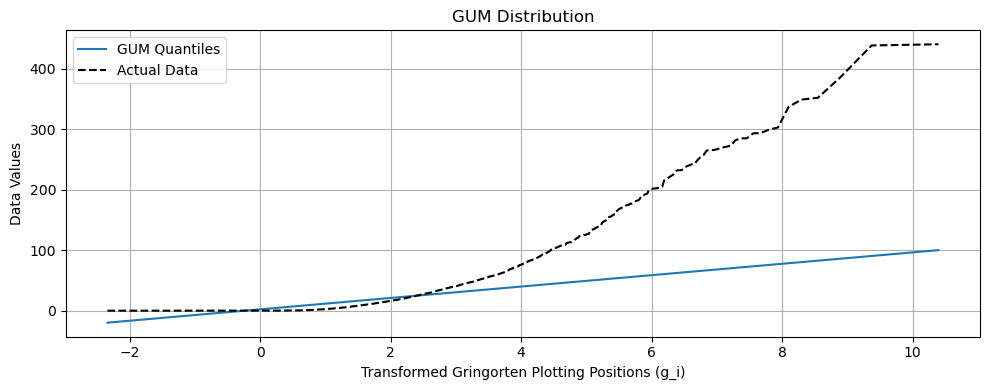

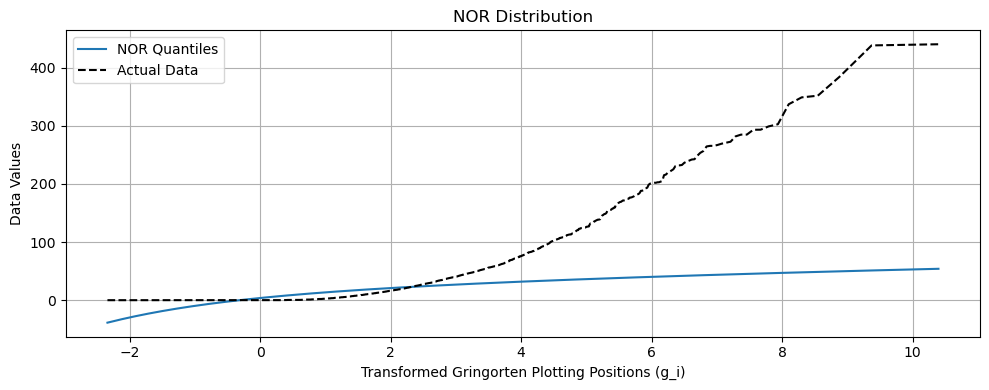

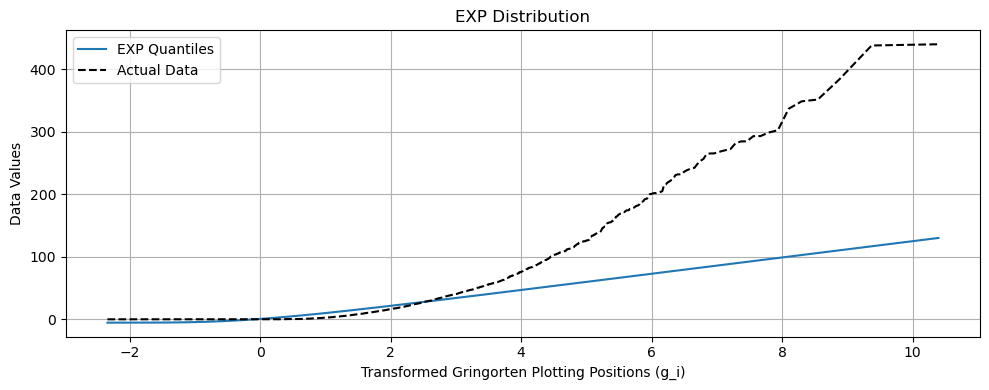

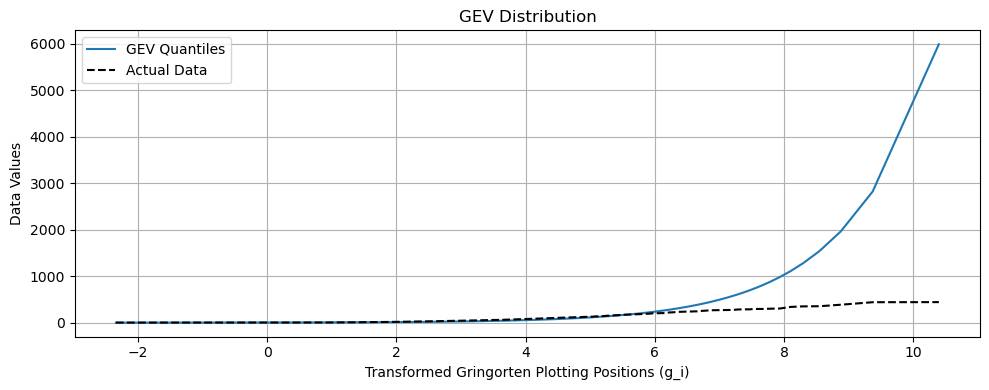

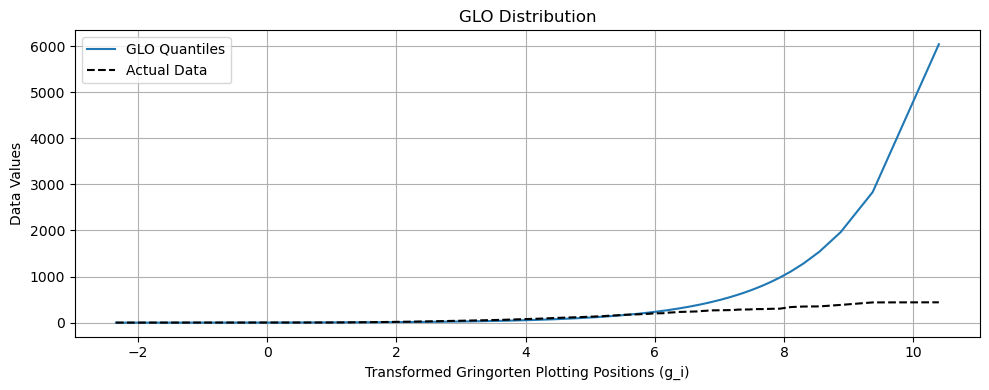

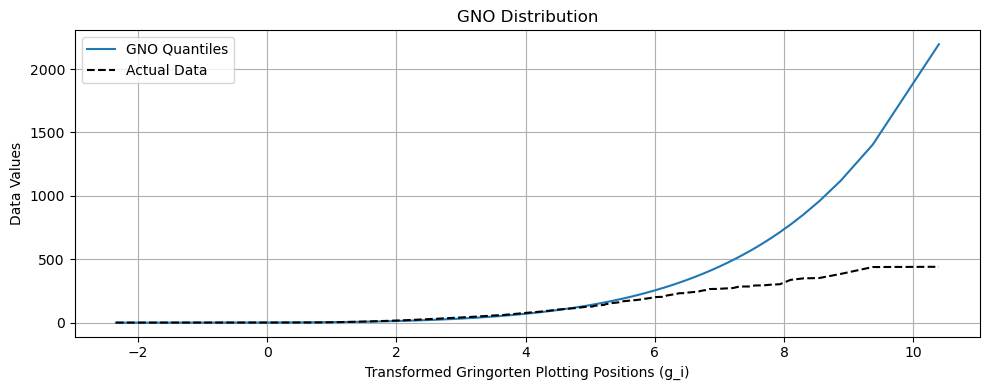

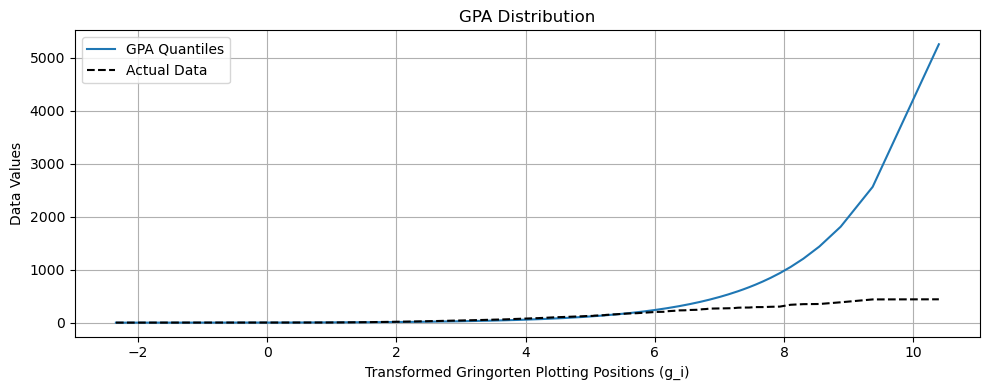

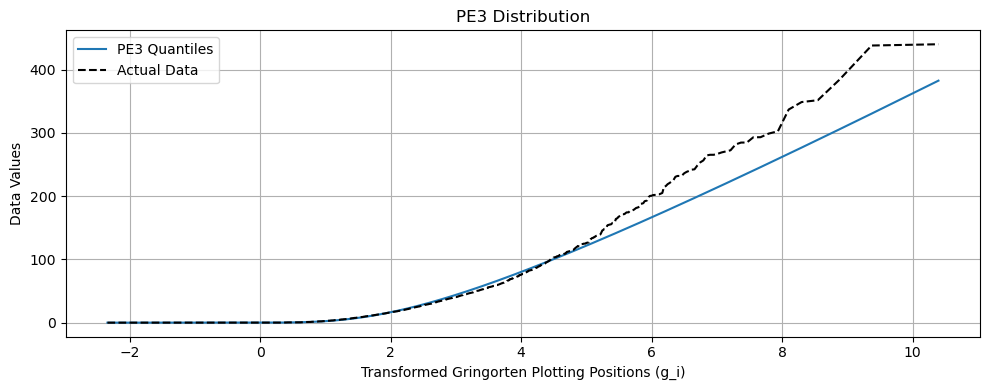

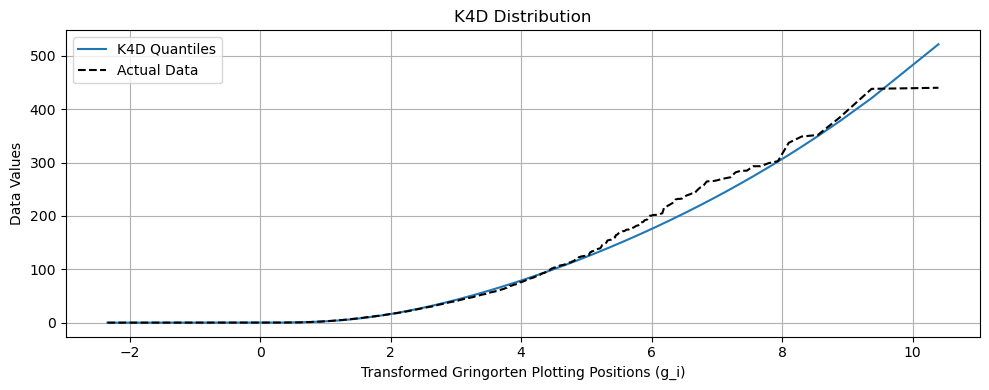

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import lmoments3 as lm
from lmoments3 import distr

# Function to calculate Gringorten plotting positions
def gringorten_plotting_positions(n):
    return [(i - 0.44) / (n + 0.12) for i in range(1, n + 1)]

# Function to calculate g_i
def calculate_gi(P_i):
    return [-np.log(-np.log(P)) for P in P_i]

# Load your data (replace with your actual data loading code)
#file_path = 'C:\\Users\\khfy3\\OneDrive\\Desktop\\MSc Data Kemaman\\Annual Maximum Kemaman.csv'
data = pd.read_csv(file_path)['Value (mm)']

# Calculate Gringorten plotting positions and g_i
n = len(data)
P_i = gringorten_plotting_positions(n)
g_i = calculate_gi(P_i)

# Fit distributions and get parameters
distributions = ['gum', 'nor','exp','gev', 'glo', 'gno', 'gpa', 'pe3',  'kap']
fitted_params = {dist: getattr(distr, dist).lmom_fit(data) for dist in distributions}

# Calculate quantiles for each distribution
quantiles = {dist: getattr(distr, dist).ppf(P_i, **params) for dist, params in fitted_params.items()}

# Sorted data for actual data plot
sorted_data = sorted(data)

# Mapping for distribution names (for titles and legends)
dist_names = {'gum': 'GUM', 'nor': 'NOR','exp':'EXP','gev': 'GEV', 'glo': 'GLO', 'gno': 'GNO', 'gpa': 'GPA', 'pe3': 'PE3',  'kap': 'K4D'}

for dist in distributions:
    # Create a new figure for each distribution
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot the quantiles and actual data
    ax.plot(g_i, quantiles[dist], label=f'{dist_names[dist]} Quantiles')
    ax.plot(g_i, sorted_data, label='Actual Data', linestyle='--', color='black')
    
    # Set titles and labels
    ax.set_title(f'{dist_names[dist]} Distribution')
    ax.set_xlabel('Transformed Gringorten Plotting Positions (g_i)')
    ax.set_ylabel('Data Values')
    
    # Add legend and grid
    ax.legend()
    ax.grid(True)
    
    # Tight layout for the current figure
    plt.tight_layout()
    
    # Save the current figure
    plt.savefig(f'plotmadi_{dist}.png')
    
    # Show the plot if needed, otherwise you can comment this out
    plt.show()
    
    # Close the current figure to free memory
    plt.close(fig)



**Calculate MADI/MSDI**
=======================

In [6]:
import numpy as np

# Ensure sorted_data is a NumPy array
sorted_data = np.array(sorted_data)

# Define weights for zero and non-zero observations
zero_weight = 0.01  # Low weight for zeros
non_zero_weight = 1  # Standard weight for non-zeros

madi = {}
msdi = {}

# Set epsilon to 1
epsilon = 1

# Calculate weights based on whether values are zero or non-zero
weights = np.where(sorted_data == 0, zero_weight, non_zero_weight)

for dist in distributions:
    # Ensure quantiles[dist] is a NumPy array for each distribution
    quantiles_dist = np.array(quantiles[dist])
    
    # Normalized differences between empirical and theoretical quantiles
    normalized_differences = (sorted_data - quantiles_dist) / (sorted_data + epsilon)
    
    # Weighted MADI
    madi[dist] = np.average(np.abs(normalized_differences), weights=weights)
    
    # Weighted MSDI
    msdi[dist] = np.average((normalized_differences)**2, weights=weights)

# Print the weighted MADI and MSDI for each distribution
for dist in distributions:
    print(f"{dist.upper()} Distribution:")
    print(f"  Weighted MADI: {madi[dist]:.4f}")
    print(f"  Weighted MSDI: {msdi[dist]:.4f}\n")


GUM Distribution:
  Weighted MADI: 2.1289
  Weighted MSDI: 7.6254

NOR Distribution:
  Weighted MADI: 2.6838
  Weighted MSDI: 12.6495

EXP Distribution:
  Weighted MADI: 1.5992
  Weighted MSDI: 3.9969

GEV Distribution:
  Weighted MADI: 0.5290
  Weighted MSDI: 0.4452

GLO Distribution:
  Weighted MADI: 0.5324
  Weighted MSDI: 0.4507

GNO Distribution:
  Weighted MADI: 0.3511
  Weighted MSDI: 0.1918

GPA Distribution:
  Weighted MADI: 0.4838
  Weighted MSDI: 0.3700

PE3 Distribution:
  Weighted MADI: 0.0552
  Weighted MSDI: 0.0039

KAP Distribution:
  Weighted MADI: 0.0439
  Weighted MSDI: 0.0028



**Combine Plot in One Graph**
=======

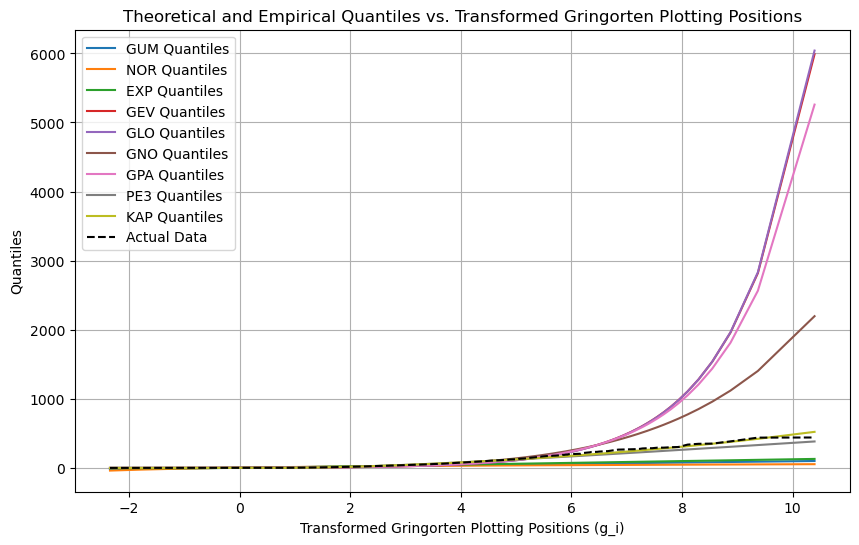

In [8]:
import matplotlib.pyplot as plt

# Assuming 'g_i' and 'quantiles' are already defined and calculated as shown earlier
plt.figure(figsize=(10, 6))

# Plot theoretical quantiles for each distribution
for dist, q in quantiles.items():
    plt.plot(g_i, q, label=f'{dist.upper()} Quantiles')

# Plot actual data
sorted_data = sorted(data)
plt.plot(g_i, sorted_data, label='Actual Data', linestyle='--', color='black')

# Labels and Title
plt.xlabel('Transformed Gringorten Plotting Positions (g_i)')
plt.ylabel('Quantiles')
plt.title('Theoretical and Empirical Quantiles vs. Transformed Gringorten Plotting Positions')

# Legend and Grid
plt.legend()
plt.grid(True)

# Specify the directory and filename for saving the plot
save_path = 'C:\\Users\\khfy3\\OneDrive\\Desktop\\Research Images\\Annual'
file_name = 'quantile_plot.png'  # You can change the filename and format as needed

# Ensure directory exists before saving (to prevent errors)
import os
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the plot to the specified file
plt.savefig(os.path.join(save_path, file_name))

# Display the plot
plt.show()
